In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
import os


In [2]:
df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../../DATA/01_corpus_metadata/full_book_data_feb_25.csv')
ucks = pd.read_excel('../../DATA/03_content_keywords/all_elements_all_ck_ucks.xlsx')

In [3]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [4]:
#get all cluster names that have visual tagging (take the cluater names values from all VT files in the folder)

folder_path = '/Users/nogashlomi/projects/Image_data/visual_tags'  # Change this to your folder path

unique_clusters_with_visual_tags = set()

for filename in os.listdir(folder_path):
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        file_path = os.path.join(folder_path, filename)
        
        try:
            if filename.endswith('.csv'):
                file_df = pd.read_csv(file_path)
            else:  # Excel file
                file_df = pd.read_excel(file_path)
            
            if 'cluster_name' in file_df.columns:
                unique_clusters_with_visual_tags.update(file_df['cluster_name'].dropna().unique())
            else:
                print(f"'cluster_name' column not found in {filename}")
        
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Now you can print or use the set as needed
# print("Unique cluster_name values across all files:")
# print(unique_clusters_with_visual_tags)


In [5]:
#add to ucks df a column with visual tagging yes or no values

# Clean label column in ucks
ucks['label'] = ucks['label'].astype(str).str.strip()

# Add the visual_tag column: 'yes' if label in unique_clusters_with_visual_tags, else 'no'
ucks['visual_tag'] = ucks['label'].apply(lambda x: 'yes' if x in unique_clusters_with_visual_tags else 'no')

# # Check the result
# print(ucks[['label', 'visual_tag']].head(10))



In [6]:
ucks

,images,label,uck,level,visual_tag
0,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
1,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
2,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
3,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
4,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_00113,MTK_Lunar Eclipse_Group_01,0,yes
...,...,...,...,...,...
216961,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01573,MVK_Diagrams,0,no
216962,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01604,MVK_Diagrams,0,yes
216963,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01604,MVK_Diagrams,0,yes
216964,http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,SAC_SIL_01607,MTK_Mercury Orbit_Group_01,0,no


In [7]:
merged_df = df.merge(
    ucks,
    how='left',
    left_on='cluster_name',
    right_on='label',
    suffixes=('', '_ucks')
).drop(columns=['label'])
merged_df

,images,cluster_name,cks,book,bid,part_or_adaption,part_or_adaption_label,type_label,custom_identifier,place,...,year_interval,place_category,latitude,longitude,printer,publisher,images_ucks,uck,level,visual_tag
0,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
1,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
2,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
3,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
4,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_01617,CK_Lunar Nodes,http://sphaera.mpiwg-berlin.mpg.de/id/item/0a7...,1624,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Tractatus de sphaera,"Annotated, Content",231.0,Paris,...,1490-1509,Large Center,48.853495,2.348391,"Hopyl, Wolfgang","Hopyl, Wolfgang",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Geocentric Cosmology,4,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17108805,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,Definition of Sphere,1,yes
17108806,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,CK_Definition of Sphere by Euclid,0,yes
17108807,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,1590-1609,Medium Center,51.489334,-0.144055,"Judson, Thomas","Jaggard, William",http://devmeta.sphaera.mpiwg-berlin.mpg.de/res...,MVK_Pictorial_Illustrations,0,yes
17108808,http://www.researchspace.org/ontology/ImageReg...,SAC_SIL_03519,CK_Definition of Sphere by Euclid,http://sphaera.mpiwg-berlin.mpg.de/id/item/e70...,2279,http://sphaera.mpiwg-berlin.mpg.de/id/part/1e2...,First part of the Sphere treatise of Thomas Hill,"Content, Original Part",928.0,London,...,15

In [8]:
# import os
# import pandas as pd

# folder_path = '/Users/nogashlomi/projects/Image_data/visual_tags'

# unique_clusters_with_visual_tags = set()

# for filename in os.listdir(folder_path):
#     if filename.endswith('.csv') or filename.endswith('.xlsx'):
#         file_path = os.path.join(folder_path, filename)
        
#         try:
#             if filename.endswith('.csv'):
#                 file_df = pd.read_csv(file_path)
#             else:
#                 file_df = pd.read_excel(file_path)
            
#             if 'cluster_name' in file_df.columns:
#                 unique_clusters_with_visual_tags.update(file_df['cluster_name'].dropna().unique())
#             else:
#                 print(f"'cluster_name' column not found in {filename}")
        
#         except Exception as e:
#             print(f"Error reading {filename}: {e}")

# # Now your original df is still intact, so you can safely run:
# df_unique_clusters = set(df['cluster_name'].dropna().unique())

# shared_clusters = df_unique_clusters.intersection(unique_clusters_with_visual_tags)

# print(f"Number of unique cluster_names in df that also appear in folder files: {len(shared_clusters)}")

# cks_groups = df.groupby('cks')['cluster_name'].apply(lambda x: set(x.dropna().unique()))

# cks_only_in_folder = cks_groups[cks_groups.apply(lambda clusters: clusters.issubset(unique_clusters_with_visual_tags))]

# print("cks values exclusively associated with cluster_names in folder files:")
# print(cks_only_in_folder.index.tolist())


In [9]:
# # Get all unique cks values from df
# unique_cks = set(df['cks'].dropna())

# # Group by cks and get their associated cluster_name sets
# cks_to_clusters = df.groupby('cks')['cluster_name'].apply(lambda x: set(x.dropna().unique()))

# # Select cks where all associated cluster_names are fully visual tagged
# visual_tagged_cks = cks_to_clusters[cks_to_clusters.apply(lambda clusters: clusters.issubset(unique_clusters_with_visual_tags))].index

# # Show results
# print(f"Total unique cks values in df: {len(unique_cks)}")
# print(f"Number of cks values with full visual tag coverage: {len(visual_tagged_cks)}")
# print(f"Percentage fully tagged: {len(visual_tagged_cks) / len(unique_cks) * 100:.2f}%")


In [10]:
# # Unique images total
# total_unique_images = df['images'].nunique()

# # Unique images with visually tagged cluster_name
# images_with_tagged_clusters = df[df['cluster_name'].isin(unique_clusters_with_visual_tags)]
# unique_tagged_images = images_with_tagged_clusters['images'].nunique()

# # Unique images without visually tagged cluster_name
# unique_untagged_images = total_unique_images - unique_tagged_images

# print(f"Total unique images: {total_unique_images}")
# print(f"Unique images with visually tagged cluster_name: {unique_tagged_images}")
# print(f"Unique images without visually tagged cluster_name: {unique_untagged_images}")
# print(f"Percentage tagged: {unique_tagged_images / total_unique_images * 100:.2f}%")
# print(f"Percentage untagged: {unique_untagged_images / total_unique_images * 100:.2f}%")


In [11]:
# # UCK values to check
# target_ucks = ['INSTRUMENTS', 'PRACTICAL ACTIVITIES', 'DISCIPLINES']

# # Make sure columns are cleaned
# ucks['uck'] = ucks['uck'].astype(str).str.strip()
# ucks['visual_tag'] = ucks['visual_tag'].astype(str).str.strip()

# # Filter the DataFrame for the desired UCK values
# filtered = ucks[ucks['uck'].isin(target_ucks)]

# # Group by 'uck' and count unique images (total)
# total_counts = filtered.groupby('uck')['images'].nunique()

# # Group by 'uck' and count unique images that are visually tagged
# tagged_counts = (
#     filtered[filtered['visual_tag'] == 'yes']
#     .groupby('uck')['images']
#     .nunique()
# )

# # Combine into one DataFrame
# result = pd.DataFrame({
#     'total_images': total_counts,
#     'tagged_images': tagged_counts
# }).fillna(0).astype(int)

# # Add percentage column
# result['percentage_tagged'] = (result['tagged_images'] / result['total_images'] * 100).round(2)

# # Show the result
# print(result)


In [12]:
# # Target UCKs (case-sensitive, exact match)
# target_ucks = [
#     'Astronomy',
#     'Geometry',
#     'Cosmography and Geography',
#     'Optics',
#     'Arithmetic',
#     'Mechanics',
#     'Meteorology',
#     'Mucis'  # Or replace with 'Music' if that's the correct value
# ]

# # Clean relevant columns
# ucks['uck'] = ucks['uck'].astype(str).str.strip()
# ucks['visual_tag'] = ucks['visual_tag'].astype(str).str.strip()

# # Total number of unique images in the entire dataset
# total_images_in_corpus = ucks['images'].nunique()

# # Filter only rows matching the target UCKs
# filtered = ucks[ucks['uck'].isin(target_ucks)]

# # Total unique image count per UCK
# total_counts = filtered.groupby('uck')['images'].nunique()

# # Tagged image count per UCK
# tagged_counts = (
#     filtered[filtered['visual_tag'] == 'yes']
#     .groupby('uck')['images']
#     .nunique()
# )

# # Combine into a result DataFrame
# result = pd.DataFrame({
#     'total_images': total_counts,
#     'tagged_images': tagged_counts
# }).fillna(0).astype(int)

# # Add percentage of tagged images (per UCK)
# result['percentage_tagged'] = (result['tagged_images'] / result['total_images'] * 100).round(2)

# # Add percentage of corpus images represented by each UCK
# result['percentage_of_corpus'] = (result['total_images'] / total_images_in_corpus * 100).round(2)

# # Display the result
# print(result)


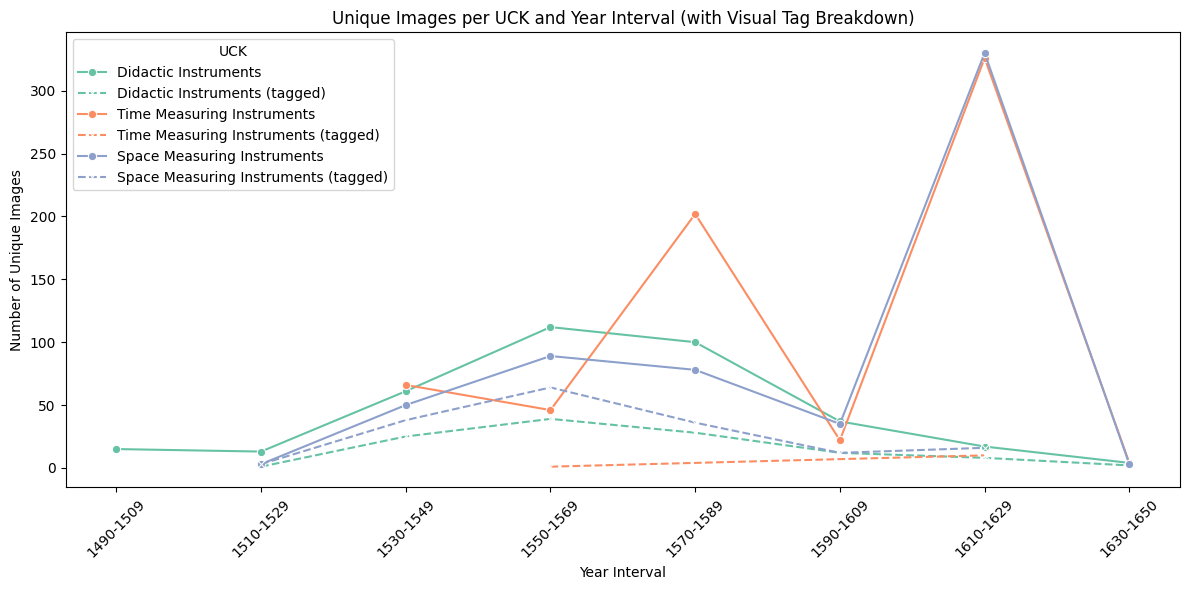

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define UCKs of interest
target_ucks = [
    'Didactic Instruments',
    'Time Measuring Instruments',
    'Space Measuring Instruments'
    ]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# ---- Filter for the selected UCKs ----
filtered = merged_df[merged_df['uck'].isin(target_ucks)].copy()

# ---- Count unique images per UCK and year_interval (all images) ----
uck_counts_all = (
    filtered.groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

# ---- Count unique images with visual_tag == 'yes' per UCK and year_interval ----
uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# ---- Combine both datasets ----
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# ---- Order year_interval ----
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# ---- Assign consistent colors to each UCK ----
palette = sns.color_palette("Set2", len(target_ucks))
uck_color_map = dict(zip(target_ucks, palette))

# ---- Plot ----
plt.figure(figsize=(12, 6))

for uck in target_ucks:
    color = uck_color_map[uck]
    
    # Solid line: all images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    # Dashed line: tagged images
    sns.lineplot(
        data=uck_combined[(uck_combined['uck'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

# # ---- Add TOTAL line (black dashed) ----
# total_counts = (
#     merged_df.groupby('year_interval')['images']
#     .nunique()
#     .reset_index()
#     .rename(columns={'images': 'num_unique_images'})
# )
# total_counts['year_interval'] = pd.Categorical(total_counts['year_interval'], categories=year_order, ordered=True)

# plt.plot(
#     total_counts['year_interval'],
#     total_counts['num_unique_images'],
#     label='TOTAL',
#     color='black',
#     linestyle='--',
#     marker='o'
# )

# ---- Final touches ----
plt.title('Unique Images per UCK and Year Interval (with Visual Tag Breakdown)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK')
plt.tight_layout()

# ---- Save and Show ----
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_instruments_lines.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_18349/1461904845.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


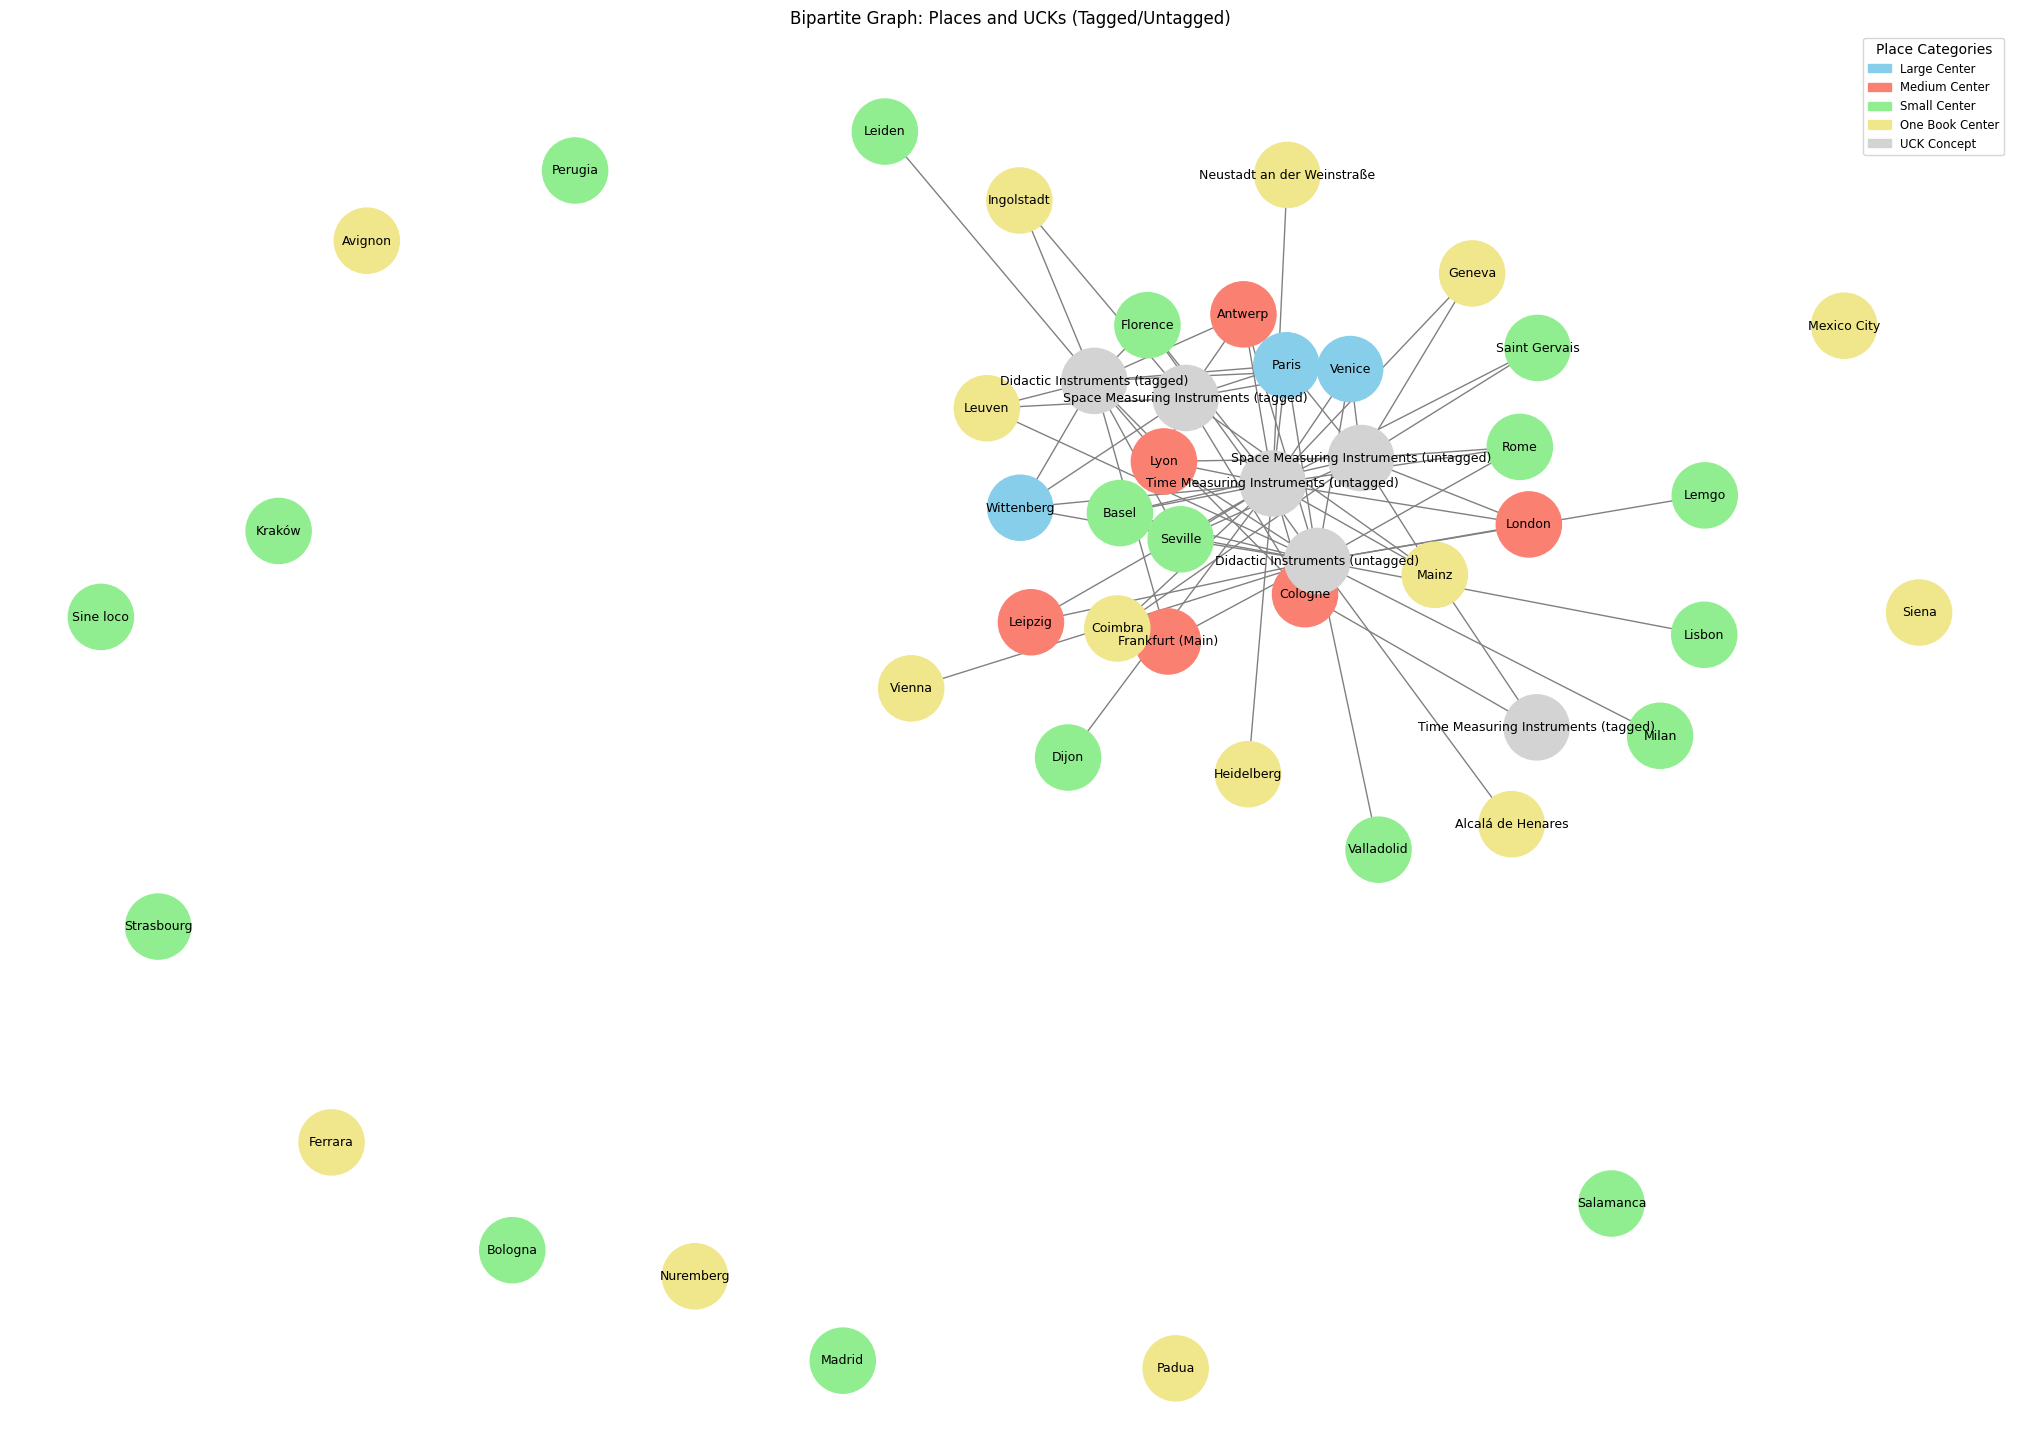

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# === Define target UCKs ===
target_uck_values =  [
    'Didactic Instruments',
    'Time Measuring Instruments',
    'Space Measuring Instruments'
]

# === Ensure string types and clean data ===
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place'] = merged_df['place'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# === Create new UCK labels with visual_tag ===
merged_df['uck_tagged'] = merged_df.apply(
    lambda row: f"{row['uck']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['uck']} (untagged)",
    axis=1
)

# === Filter for target UCKs only ===
filtered_df = merged_df[merged_df['uck'].isin(target_uck_values)].copy()

# === Get unique places from the full dataframe ===
all_places = merged_df['place'].unique().tolist()

# === Create edges (place ↔ tagged_uck) ===
edges = list(zip(filtered_df['place'], filtered_df['uck_tagged']))

# === Map place categories to colors ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = merged_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in all_places:
    cat_series = merged_df[merged_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Build Graph ===
G = nx.Graph()
G.add_nodes_from(all_places, bipartite=0)

# Add tagged/untagged UCK nodes
uck_nodes = filtered_df['uck_tagged'].unique().tolist()
G.add_nodes_from(uck_nodes, bipartite=1)

# Add edges
G.add_edges_from(edges)

# === Assign node colors ===
node_colors = [
    place_color_map[node] if node in all_places else 'lightgray'
    for node in G.nodes()
]

# === Draw Graph ===
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

# === Add Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and UCKs (Tagged/Untagged)")
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_instruments_place_network.png', dpi=300)


plt.show()


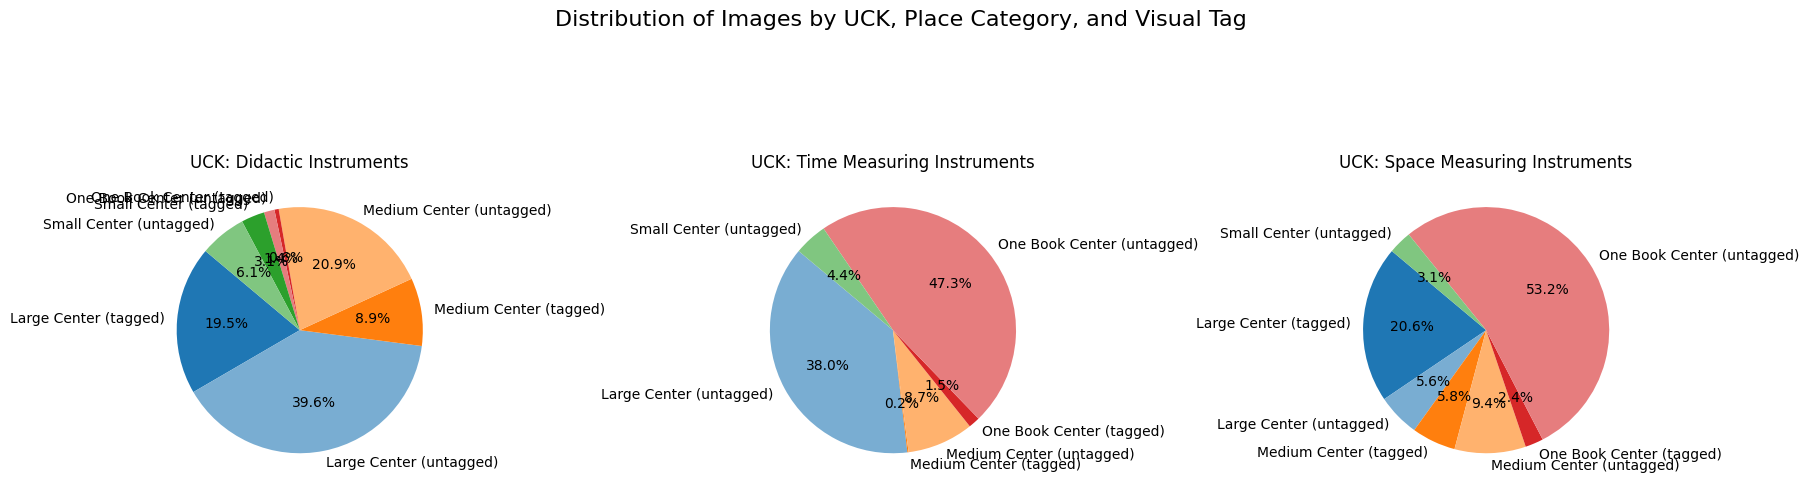

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Ensure columns are clean ---
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# --- Define UCKs of interest ---
target_uck_values = [
     'Didactic Instruments',
    'Time Measuring Instruments',
    'Space Measuring Instruments'
]

# --- Define consistent base colors for each place category ---
base_colors = {
    'Large Center': '#1f77b4',     # blue
    'Medium Center': '#ff7f0e',    # orange
    'Small Center': '#2ca02c',     # green
    'One Book Center': '#d62728'   # red
}

# Generate lighter (desaturated) version for untagged
def desaturate(color_hex, amount=0.4):
    rgb = mcolors.to_rgb(color_hex)
    return mcolors.to_hex([(1 - amount) * c + amount for c in rgb])

# Create full color map for pie slices
pie_color_map = {}
for cat, base in base_colors.items():
    pie_color_map[f'{cat} (tagged)'] = base
    pie_color_map[f'{cat} (untagged)'] = desaturate(base)

# --- Prepare subplot layout: 2 rows, 3 columns (to fit 5 plots) ---
n_rows = 1
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

# Flatten axes for easy indexing
axes = axes.flatten()

for i, uck in enumerate(target_uck_values):
    ax = axes[i]

    # Filter for current UCK
    subset_df = merged_df[merged_df['uck'] == uck].copy()

    # Skip if no data
    if subset_df.empty:
        print(f"⚠️ No data found for UCK: {uck}")
        ax.axis('off')
        continue

    # Create group label: e.g. 'Large Center (tagged)' or 'Small Center (untagged)'
    subset_df['group_label'] = subset_df.apply(
        lambda row: f"{row['place_category']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['place_category']} (untagged)",
        axis=1
    )

    # Group and count unique images
    grouped = (
        subset_df.groupby('group_label')['images']
        .nunique()
        .reset_index()
        .rename(columns={'images': 'num_images'})
    )

    # Remove 0-counts
    grouped = grouped[grouped['num_images'] > 0]

    # Skip if no valid data
    if grouped.empty:
        print(f"⚠️ No image data to plot for UCK: {uck}")
        ax.axis('off')
        continue

    # Map colors for pie slices
    slice_colors = [pie_color_map.get(label, 'gray') for label in grouped['group_label']]

    # Plot pie chart
    ax.pie(
        grouped['num_images'],
        labels=grouped['group_label'],
        autopct='%1.1f%%',
        startangle=140,
        colors=slice_colors
    )
    ax.set_title(f'UCK: {uck}', fontsize=12)

# Turn off any unused subplots (e.g. last one if only 5 UCKs)
for j in range(len(target_uck_values), len(axes)):
    axes[j].axis('off')

# Final layout adjustment
plt.suptitle("Distribution of Images by UCK, Place Category, and Visual Tag", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and show
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_instruments_cat_pies.png', dpi=300)
plt.show()


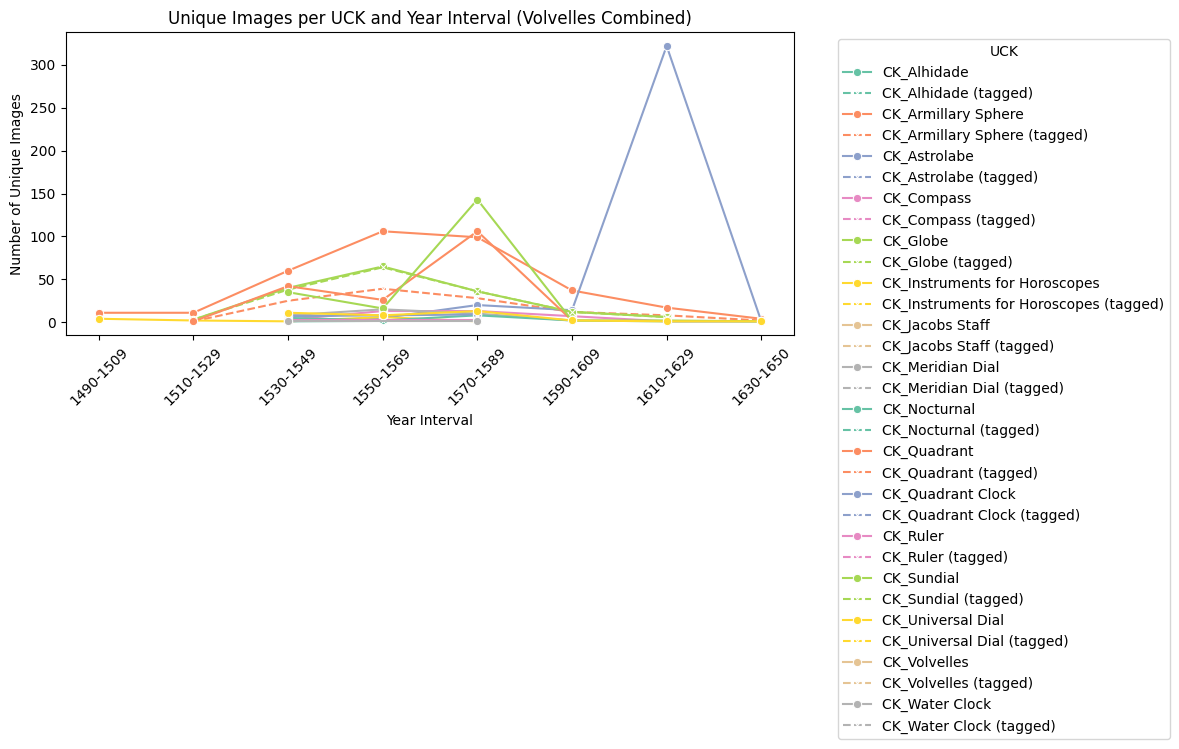

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define volvelle-related UCKs
volvelle_ucks = [
    'CK_Volvelles Mixed Parts',
    'CK_Volvelles Incorrectly Assembled',
    'CK_Volvelles for Eclipse',
    'CK_Volvelles for Horizon',
    'CK_Volvelles for Zodiac',
    'CK_Volvelles for Heliacal',
    'CK_Volvelles for Moon Day Location',
    'CK_Volvelles for Time Meridian',
    'CK_Volvelles for North East',
    'CK_Volvelles for North Star',
    'CK_Volvelles for Rising Setting Sun Latitudinal',
    'CK_Volvelles for Tides',
]

# Full target list
target_ucks = [
    'CK_Instruments for Horoscopes',
    'CK_Armillary Sphere',
    *volvelle_ucks,
    'CK_Universal Dial',
    'CK_Meridian Dial',
    'CK_Quadrant Clock',
    'CK_Sundial',
    'CK_Nocturnal',
    'CK_Astrolabe',
    'CK_Water Clock',
    'CK_Quadrant',
    'CK_Globe',
    'CK_Compass',
    'CK_Ruler',
    'CK_Jacobs Staff',
    'CK_Alhidade'
]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# Map volvelles to one label
merged_df['uck_mapped'] = merged_df['uck'].apply(lambda x: 'CK_Volvelles' if x in volvelle_ucks else x)

# Filter for selected UCKs
selected_ucks = list(set(['CK_Volvelles'] + [uck for uck in target_ucks if uck not in volvelle_ucks]))
filtered = merged_df[merged_df['uck_mapped'].isin(selected_ucks)].copy()

# Group and count unique images
uck_counts_all = (
    filtered.groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# Combine
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# Order year intervals
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# Color palette
palette = sns.color_palette("Set2", len(selected_ucks))
uck_color_map = dict(zip(sorted(selected_ucks), palette))

# Plot
plt.figure(figsize=(12, 6))

for uck in sorted(selected_ucks):
    color = uck_color_map[uck]
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

plt.title('Unique Images per UCK and Year Interval (Volvelles Combined)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_specific_instruments_lines.png', dpi=300)


plt.show()


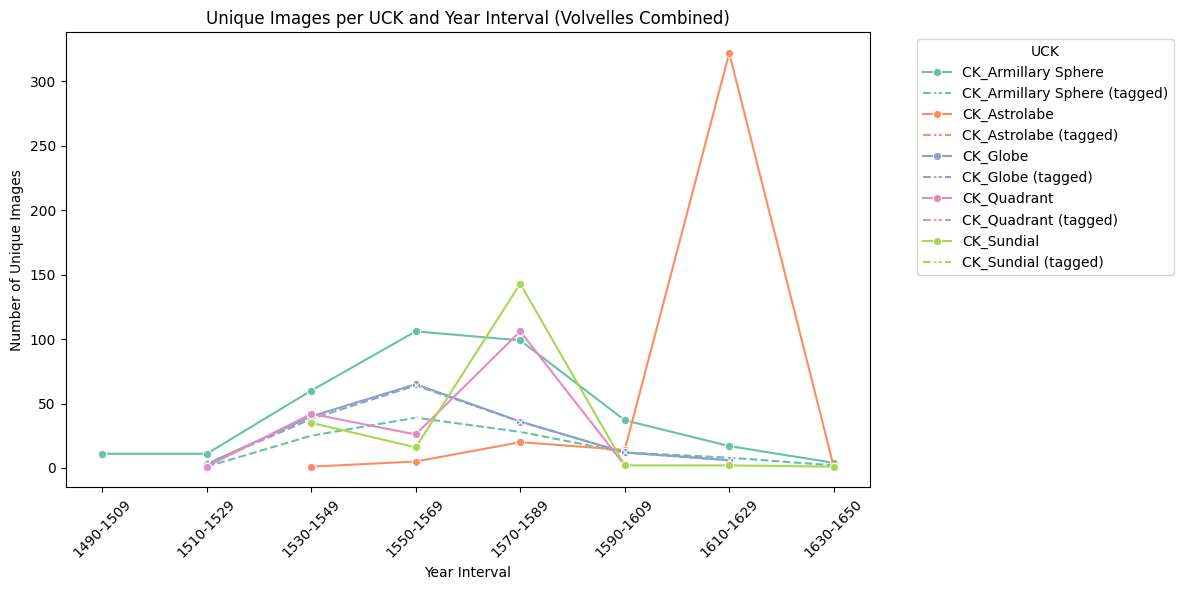

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define volvelle-related UCKs
volvelle_ucks = [
    'CK_Volvelles Mixed Parts',
    'CK_Volvelles Incorrectly Assembled',
    'CK_Volvelles for Eclipse',
    'CK_Volvelles for Horizon',
    'CK_Volvelles for Zodiac',
    'CK_Volvelles for Heliacal',
    'CK_Volvelles for Moon Day Location',
    'CK_Volvelles for Time Meridian',
    'CK_Volvelles for North East',
    'CK_Volvelles for North Star',
    'CK_Volvelles for Rising Setting Sun Latitudinal',
    'CK_Volvelles for Tides',
]

# Full target list
target_ucks = [
    # 'CK_Instruments for Horoscopes',
    'CK_Armillary Sphere',
    # *volvelle_ucks,
    # 'CK_Universal Dial',
    # 'CK_Meridian Dial',
    # 'CK_Quadrant Clock',
    'CK_Sundial',
    # 'CK_Nocturnal',
    'CK_Astrolabe',
    # 'CK_Water Clock',
    'CK_Quadrant',
    'CK_Globe',
    # 'CK_Compass',
    # 'CK_Ruler',
    # 'CK_Jacobs Staff',
    # 'CK_Alhidade'
]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# Map volvelles to one label
merged_df['uck_mapped'] = merged_df['uck'].apply(lambda x: 'CK_Volvelles' if x in volvelle_ucks else x)

# Filter for selected UCKs
selected_ucks = list(set(['CK_Volvelles'] + [uck for uck in target_ucks if uck not in volvelle_ucks]))
filtered = merged_df[merged_df['uck_mapped'].isin(selected_ucks)].copy()

# Group and count unique images
uck_counts_all = (
    filtered.groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# Combine
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# Order year intervals
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# Color palette
palette = sns.color_palette("Set2", len(selected_ucks))
uck_color_map = dict(zip(sorted(selected_ucks), palette))

# Plot
plt.figure(figsize=(12, 6))

for uck in sorted(selected_ucks):
    if uck == 'CK_Volvelles':  # Comment out volvelles plotting to exclude from graph
        # Uncomment below lines to plot volvelles combined
        # color = uck_color_map[uck]
        
        # sns.lineplot(
        #     data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == False)],
        #     x='year_interval',
        #     y='num_unique_images',
        #     label=uck,
        #     color=color,
        #     marker='o'
        # )
        
        # sns.lineplot(
        #     data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == True)],
        #     x='year_interval',
        #     y='num_unique_images',
        #     label=f"{uck} (tagged)",
        #     color=color,
        #     linestyle='--',
        #     marker='x'
        # )
        continue
    
    color = uck_color_map[uck]
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

plt.title('Unique Images per UCK and Year Interval (Volvelles Combined)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_specific_instruments_lines.png', dpi=300)

plt.show()


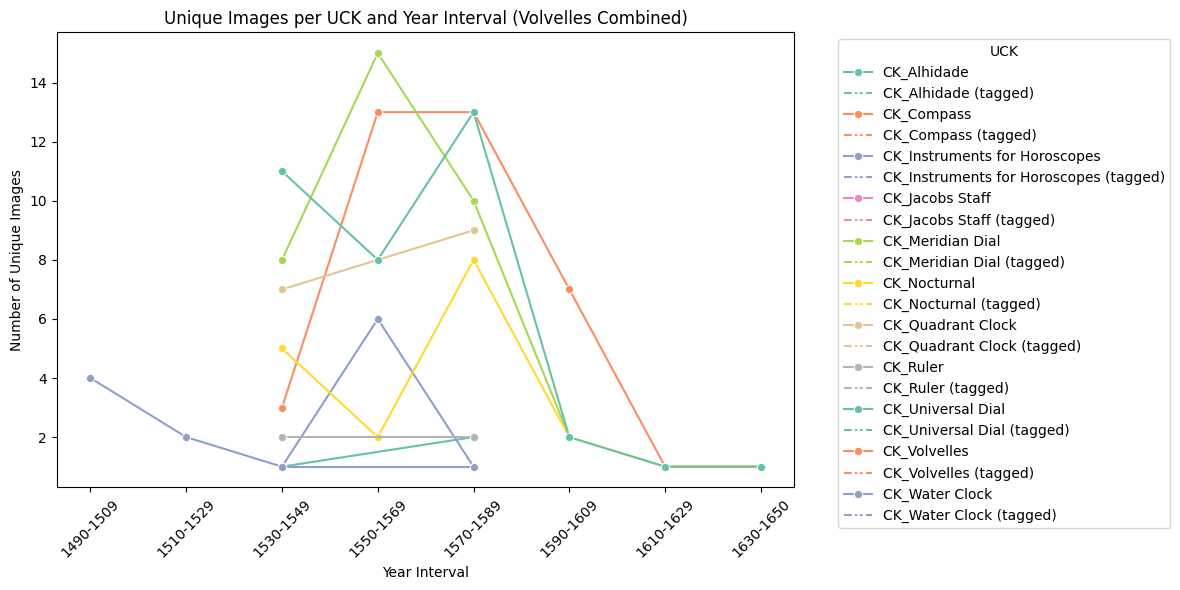

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define volvelle-related UCKs
volvelle_ucks = [
    'CK_Volvelles Mixed Parts',
    'CK_Volvelles Incorrectly Assembled',
    'CK_Volvelles for Eclipse',
    'CK_Volvelles for Horizon',
    'CK_Volvelles for Zodiac',
    'CK_Volvelles for Heliacal',
    'CK_Volvelles for Moon Day Location',
    'CK_Volvelles for Time Meridian',
    'CK_Volvelles for North East',
    'CK_Volvelles for North Star',
    'CK_Volvelles for Rising Setting Sun Latitudinal',
    'CK_Volvelles for Tides',
]

# Full target list
target_ucks = [
    'CK_Instruments for Horoscopes',
    # 'CK_Armillary Sphere',
    *volvelle_ucks,
    'CK_Universal Dial',
    'CK_Meridian Dial',
    'CK_Quadrant Clock',
    # 'CK_Sundial',
    'CK_Nocturnal',
    # 'CK_Astrolabe',
    'CK_Water Clock',
    # 'CK_Quadrant',
    # 'CK_Globe',
    'CK_Compass',
    'CK_Ruler',
    'CK_Jacobs Staff',
    'CK_Alhidade'
]

# Clean columns
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['year_interval'] = merged_df['year_interval'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()

# Map volvelles to one label
merged_df['uck_mapped'] = merged_df['uck'].apply(lambda x: 'CK_Volvelles' if x in volvelle_ucks else x)

# Filter for selected UCKs
selected_ucks = list(set(['CK_Volvelles'] + [uck for uck in target_ucks if uck not in volvelle_ucks]))
filtered = merged_df[merged_df['uck_mapped'].isin(selected_ucks)].copy()

# Group and count unique images
uck_counts_all = (
    filtered.groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_all['tagged'] = False

uck_counts_tagged = (
    filtered[filtered['visual_tag'] == 'yes']
    .groupby(['uck_mapped', 'year_interval'])['images']
    .nunique()
    .reset_index()
    .rename(columns={'images': 'num_unique_images'})
)
uck_counts_tagged['tagged'] = True

# Combine
uck_combined = pd.concat([uck_counts_all, uck_counts_tagged], ignore_index=True)

# Order year intervals
year_order = sorted(uck_combined['year_interval'].unique())
uck_combined['year_interval'] = pd.Categorical(uck_combined['year_interval'], categories=year_order, ordered=True)

# Color palette
palette = sns.color_palette("Set2", len(selected_ucks))
uck_color_map = dict(zip(sorted(selected_ucks), palette))

# Plot
plt.figure(figsize=(12, 6))

for uck in sorted(selected_ucks):
    color = uck_color_map[uck]
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == False)],
        x='year_interval',
        y='num_unique_images',
        label=uck,
        color=color,
        marker='o'
    )
    
    sns.lineplot(
        data=uck_combined[(uck_combined['uck_mapped'] == uck) & (uck_combined['tagged'] == True)],
        x='year_interval',
        y='num_unique_images',
        label=f"{uck} (tagged)",
        color=color,
        linestyle='--',
        marker='x'
    )

plt.title('Unique Images per UCK and Year Interval (Volvelles Combined)')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='UCK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/5_specific_instruments_lines_b.png', dpi=300)

plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_18349/3831759662.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


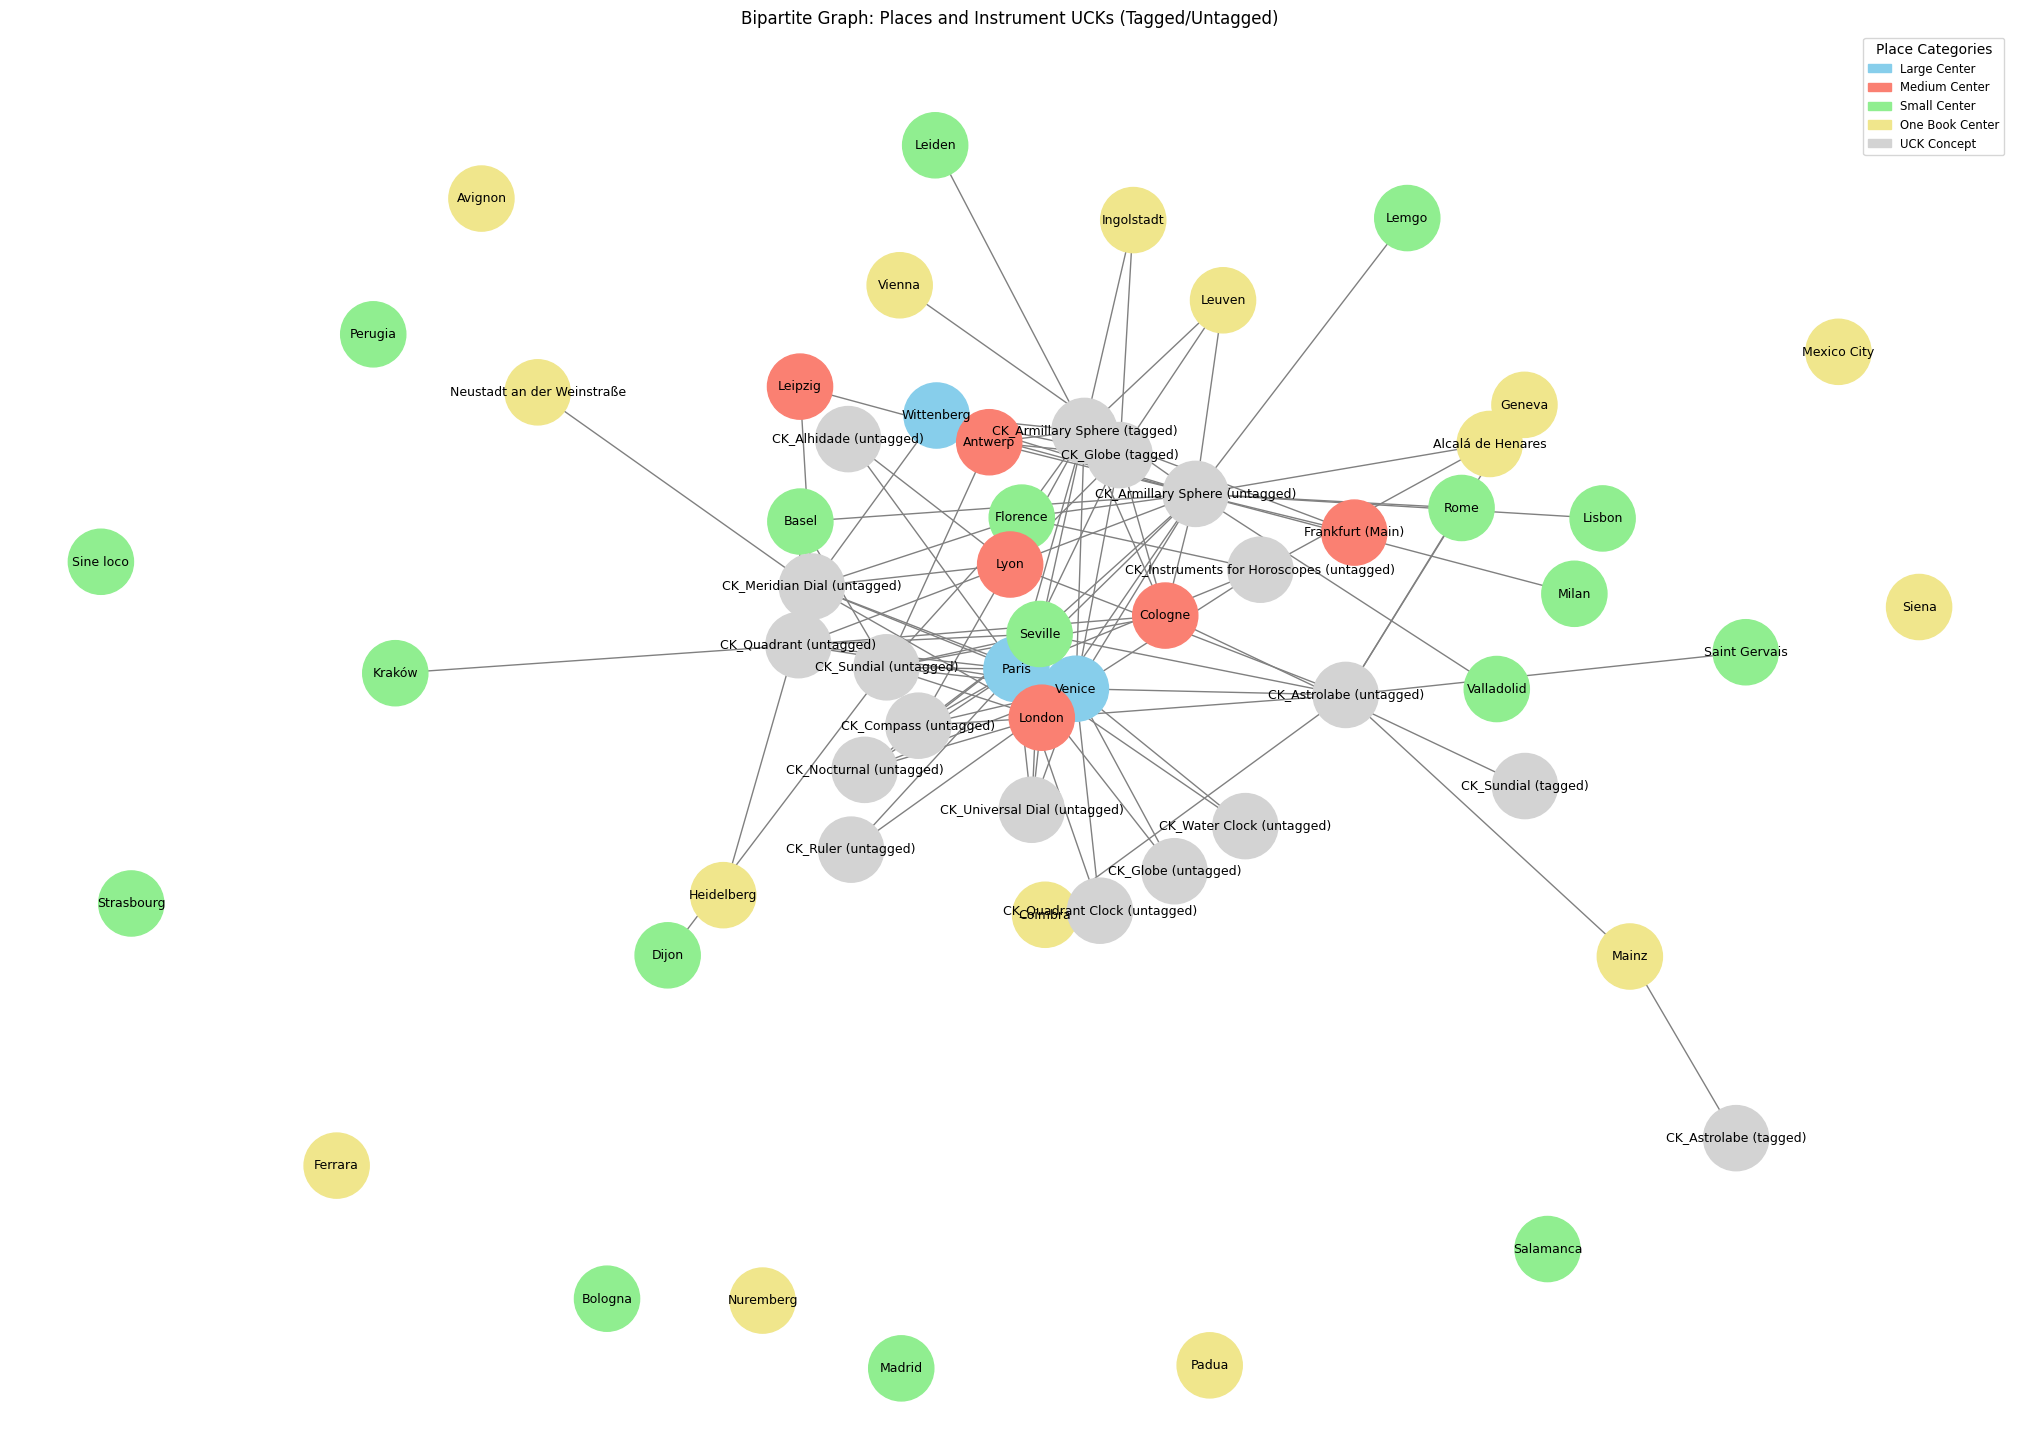

In [36]:
# --- Step 1: Define UCKs ---
volvelle_ucks = [
    'CK_Volvelles Mixed Parts',
    'CK_Volvelles Incorrectly Assembled',
    'CK_Volvelles for Eclipse',
    'CK_Volvelles for Horizon',
    'CK_Volvelles for Zodiac',
    'CK_Volvelles for Heliacal',
    'CK_Volvelles for Moon Day Location',
    'CK_Volvelles for Time Meridian',
    'CK_Volvelles for North East',
    'CK_Volvelles for North Star',
    'CK_Volvelles for Rising Setting Sun Latitudinal',
    'CK_Volvelles for Tides'
]

# All UCKs of interest, including non-volvelle ones
target_uck_values = [
    'CK_Instruments for Horoscopes',
    'CK_Armillary Sphere',
    'CK_Universal Dial',
    'CK_Meridian Dial',
    'CK_Quadrant Clock',
    'CK_Sundial',
    'CK_Nocturnal',
    'CK_Astrolabe',
    'CK_Water Clock',
    'CK_Quadrant',
    'CK_Globe',
    'CK_Compass',
    'CK_Ruler',
    'CK_Jacobs Staff',
    'CK_Alhidade'
] + volvelle_ucks

# --- Step 2: Preprocess ---
merged_df['uck'] = merged_df['uck'].astype(str).str.strip()
merged_df['visual_tag'] = merged_df['visual_tag'].astype(str).str.strip()
merged_df['place'] = merged_df['place'].astype(str).str.strip()
merged_df['place_category'] = merged_df['place_category'].astype(str).str.strip()

# --- Step 3: Map all volvelles to one name ---
merged_df['uck_mapped'] = merged_df['uck'].apply(
    lambda x: 'CK_Volvelles' if x in volvelle_ucks else x
)

# --- Step 4: Apply tagged/untagged label ---
merged_df['uck_tagged'] = merged_df.apply(
    lambda row: f"{row['uck_mapped']} (tagged)" if row['visual_tag'].lower() == 'yes' else f"{row['uck_mapped']} (untagged)",
    axis=1
)

# --- Step 5: Filter only relevant rows ---
filtered_df = merged_df[merged_df['uck'].isin(target_uck_values)].copy()

# --- Graph edges ---
edges = list(zip(filtered_df['place'], filtered_df['uck_tagged']))

# --- Place colors by category ---
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
existing_categories = merged_df['place_category'].dropna().unique().tolist()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in merged_df['place'].unique():
    cat_series = merged_df[merged_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# --- Build graph ---
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.Graph()
places = merged_df['place'].unique()
uck_nodes = filtered_df['uck_tagged'].unique()

G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(uck_nodes, bipartite=1)
G.add_edges_from(edges)

node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

# --- Draw ---
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, seed=42, k=0.45)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2200,
    font_size=9
)

legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='UCK Concept'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Instrument UCKs (Tagged/Untagged)")
plt.tight_layout()
plt.show()
